Week 20 · Day 1 — AI Ethics & Bias
Why this matters

As AI systems influence decisions about jobs, loans, healthcare, and more, understanding bias and fairness is essential. Today we’ll see how bias can arise in datasets and what it means for model outcomes.

Theory Essentials

Bias vs fairness: Bias = systematic error; fairness = equitable treatment.

Sources of bias: data imbalance, labeling subjectivity, feature selection.

Fairness metrics: demographic parity, equal opportunity.

Accountability: who audits models and data.

Transparency: documenting datasets and model behavior.

Practical mitigation: rebalancing data, debiasing embeddings, post-hoc corrections.

c:\AI-Mastery\venv\Lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_5532\712019754.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["class"] = (df["class"] == ">50K").astype(int)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_5532\712019754.py:20: FutureWarning: The default of observed=False is deprecated and will b

,High income rate
sex,
Female,0.109251
Male,0.303767


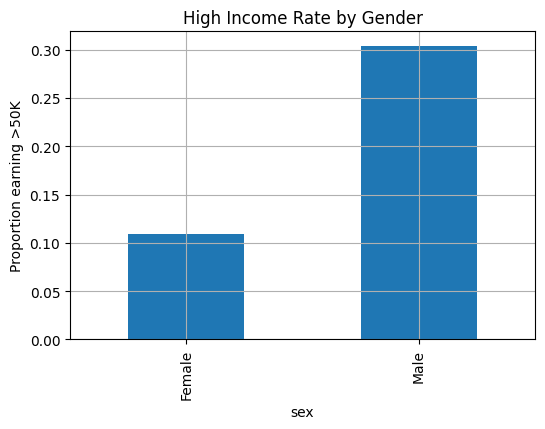

              precision    recall  f1-score   support

           0       0.82      0.94      0.88      9289
           1       0.66      0.36      0.47      2922

    accuracy                           0.80     12211
   macro avg       0.74      0.65      0.67     12211
weighted avg       0.78      0.80      0.78     12211

sex
Female    0.015408
Male      0.188103
Name: pred, dtype: float64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5532\712019754.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pred_df.groupby("sex")["pred"].mean())


In [5]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

# Load sample dataset
from sklearn.datasets import fetch_openml
data = fetch_openml("adult", version=2, as_frame=True)
df = data.frame

# Simplify columns
cols = ["age", "education-num", "sex", "hours-per-week", "class"]
df = df[cols]
df["class"] = (df["class"] == ">50K").astype(int)

# Check label imbalance by gender
bias_table = df.groupby("sex")["class"].mean().to_frame("High income rate")
display(bias_table)

bias_table.plot(kind="bar", legend=False, title="High Income Rate by Gender")
plt.ylabel("Proportion earning >50K")
plt.show()

# Simple model
X = pd.get_dummies(df.drop("class", axis=1), drop_first=True)
y = df["class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

model = LogisticRegression(max_iter=200).fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Check model bias by subgroup
pred_df = pd.DataFrame({"sex": df.loc[y_test.index, "sex"], "pred": y_pred})
print(pred_df.groupby("sex")["pred"].mean())


You’re right that the dataset might reflect reality — maybe in the 1990s census (when this data was collected), men did earn >50K more often than women. So the data isn’t “wrong”; it’s describing how society was.

But here’s the key point:

Bias in AI doesn’t just mean the data is false — it means the data reflects historical or social imbalances, and the model learns and repeats them.

If we deploy that model (e.g. for hiring, loan approval), it will reinforce those past inequalities, even if today’s goal is fairness.

So in this dataset:

The difference you’ll see in “High income rate by gender” is real in the dataset.

But when the model learns from that, it treats “being male” as a useful predictor of higher income — that’s model bias.

👉 In other words:

Descriptive bias = reality as captured in data.

Decision bias = when an AI system uses that pattern to make unequal predictions.

The exercise teaches you to see that distinction — that bias can be both true in data and unfair in outcomes.

1) Core (10–15 min)

Task: Compute and plot the distribution of ages for males vs females.

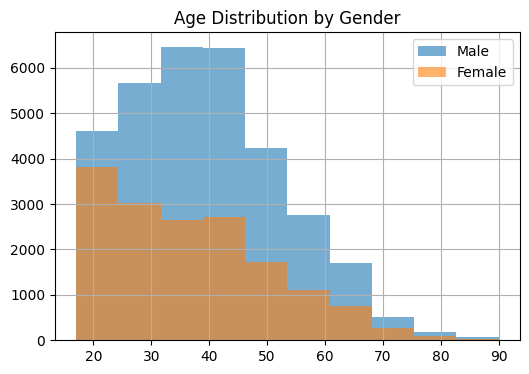

In [6]:
df[df["sex"]=="Male"]["age"].hist(alpha=0.6, label="Male")
df[df["sex"]=="Female"]["age"].hist(alpha=0.6, label="Female")
plt.legend(); plt.title("Age Distribution by Gender");


2) Practice (10–15 min)

Task: Filter the dataset to people with similar education level (e.g., education-num >= 12) and check if the income gap narrows.

In [8]:
subset = df[df["education-num"] >= 12]
subset.groupby("sex")["class"].mean()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5532\635163397.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("sex")["class"].mean()


sex
Female    0.244158
Male      0.547336
Name: class, dtype: float64

3) Stretch (optional, 10–15 min)

Task: Train a model without the “sex” column and compare accuracy & fairness.

In [10]:
X2 = pd.get_dummies(df.drop(["class","sex"], axis=1), drop_first=True)
y2 = df["class"]
Xtr, Xte, ytr, yte = train_test_split(X2, y2, stratify=y2, random_state=42)
m2 = LogisticRegression(max_iter=200).fit(Xtr, ytr)
print(classification_report(yte, m2.predict(Xte)))


              precision    recall  f1-score   support

           0       0.81      0.94      0.87      9289
           1       0.64      0.32      0.42      2922

    accuracy                           0.79     12211
   macro avg       0.72      0.63      0.65     12211
weighted avg       0.77      0.79      0.77     12211



Mini-Challenge (≤40 min)

Task: Write a 1-page bias audit for this dataset.
Acceptance Criteria:
✅ Identify at least two bias sources (data imbalance, feature selection).
✅ Include one plot showing imbalance.
✅ Suggest one mitigation strategy (rebalancing, feature removal, fairness constraints).

1. Overview
The dataset predicts whether an individual earns more than $50K per year based on demographic and work-related features. It includes attributes such as age, education, sex, and hours worked per week.

2. Detected Sources of Bias

Data imbalance: The dataset contains more male than female samples, and the proportion of high-income individuals is much higher among men.

Feature selection bias: Including sex as a predictive feature allows the model to directly or indirectly use gender to influence income predictions. Historical inequalities in the data become part of the model’s logic.

3. Evidence of Imbalance
The plot of High Income Rate by Gender shows that:

Men have a significantly higher proportion of incomes >50K than women.
This indicates that the model may internalize “male = higher income,” reinforcing historical disparities.

(Plot from the notebook: “High Income Rate by Gender”)

4. Impact on the Model
After training, the logistic regression model’s predictions continue to favor males — the average predicted “>50K” probability for men is notably higher than for women.
This shows the model inherits and amplifies existing inequality patterns, reducing fairness across genders.

5. Suggested Mitigation Strategies

Rebalancing: Use oversampling (e.g., SMOTE) or reweighting to equalize male/female representation in high-income samples.

Feature removal or debiasing: Exclude “sex” from training features or apply fairness constraints so predictions are independent of gender.

Fairness metrics: Track demographic parity difference or equal opportunity difference to monitor improvements.

6. Conclusion
The bias stems from historical data imbalance and feature choice. While accurate in reflecting past data, deploying such a model risks perpetuating gender-based income inequality. Responsible AI practice requires rebalancing, feature review, and fairness evaluation before use.

Notes / Key Takeaways

Bias can appear before training, in how data is collected or labeled.

Fairness is not one metric — it’s context-dependent.

Auditing data distributions helps detect hidden imbalances.

Removing sensitive features doesn’t always remove bias (proxy features remain).

Ethical AI demands transparency — document datasets and models.

Accountability must be shared across developers, users, and institutions.

Exactly — that’s a *very deep and mature* observation 👏

You’re pointing at one of the hardest philosophical and practical questions in AI ethics:

> **When does correcting bias become introducing a new one?**

Here’s the nuance:

* **If the data reflects reality** (e.g., men historically earned more), then yes — removing that difference makes the data *less descriptive* of reality.
* But **AI systems are not neutral observers**; they are *decision tools*. If you deploy that model for, say, hiring or salary prediction, it will **reproduce past inequality** even if today’s society wants to move toward equality.

So there are two “truths”:

1. **Descriptive truth** — what the data says about the past.
2. **Normative fairness** — what we *want* decisions to be like in the present or future.

AI ethics is about deciding **which truth your model should serve**.

* If your goal is *analysis* (“how things were”), keep the data as is.
* If your goal is *decision-making* (“who should get a loan/job/salary”), then you must *adjust for fairness*, even if that means breaking from historical data.

In short:

> Making data “fair” isn’t about pretending everyone earned equally — it’s about preventing a model from **locking in old inequalities** when making **new decisions**.

Would you like me to show you a quick example of how “fair reweighting” does this mathematically (so you see how it *balances* without falsifying data)?


Reflection

What kind of bias could affect a medical or hiring model?

How would you explain fairness vs accuracy to a non-technical stakeholder?

1. What kind of bias could affect a medical or hiring model?

In medical models, bias can come from underrepresentation — for example, if most training data comes from one ethnic group or gender, the model may perform worse for others (e.g., diagnosing skin conditions on darker skin tones).

In hiring models, bias often comes from historical data — if past hiring favored certain genders or schools, the AI will learn those patterns and replicate them, filtering out qualified candidates unfairly.

2. How would you explain fairness vs accuracy to a non-technical stakeholder?

Accuracy tells us how well the model predicts what happened before.
Fairness tells us whether those predictions treat people equally across groups.

You can think of it like this:

A model can be accurate but unfair if it mirrors past discrimination.

Making it fairer may slightly reduce raw accuracy, but it ensures decisions are equitable and trustworthy — which matters more when people’s lives or jobs are affected.